In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats as sps
from scipy import stats, optimize
from scipy.special import digamma, polygamma
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

Splicing junction outliers from leafcutter and MIGs from Frazier
-

In [3]:
# to extract only the significant outliers 
def bh_series(s: pd.Series) -> pd.Series:
    m = s.notna()
    if m.sum() == 0:
        return s  
    q = np.full_like(s.astype(float).to_numpy(), np.nan, dtype=float)
    q[m] = multipletests(s[m].astype(float).to_numpy(), method='fdr_bh')[1]
    return pd.Series(q, index=s.index)

def extract_sig_effects(wm: pd.DataFrame, wme: pd.DataFrame, alpha: float = 0.05) -> pd.DataFrame:
    """
    wm  : q-values (rows=junctions, cols=samples)
    wme : effect sizes (same shape)
    """
    # Align shapes/labels
    wme = wme.reindex(index=wm.index, columns=wm.columns)

    # Name the axes so stack gives us meaningful column names
    wm = wm.copy()
    wm.index.name = wm.index.name or "junction"
    wm.columns.name = wm.columns.name or "sample"

    wme = wme.copy()
    wme.index.name = wm.index.name
    wme.columns.name = wm.columns.name

    # Keep effect sizes only where q < alpha
    effects_sig = wme.where(wm < alpha)

    # Long form, drop NaNs
    ser = effects_sig.stack(dropna=True).rename("effect_size")  
    out = ser.reset_index()  

    # Ensure final column order
    out = out[["sample", "effect_size", "junction"]]
    return out

In [4]:
#for the standard samples
wm = pd.read_csv("applied_depletion_gregor_n100/leafcutter/WM_pVals.txt", sep="\t")
wm = wm.apply(bh_series, axis=0)
wm = wm.loc[wm.min(axis=1) < 0.05, :]
wm.to_csv("applied_depletion_gregor_n100/leafcutter/WM_pVals_bh_sig_hits.txt", sep="\t", index=True)

wme = pd.read_csv("applied_depletion_gregor_n100/leafcutter/WM_effSize.txt", sep="\t")
wme = wme.loc[wm.index, :]

#now we build an effect size dataframe 
sig_effects_wm = extract_sig_effects(wm, wme, alpha=0.05)
sig_effects_wm['condition'] = 'Standard'
sig_effects_wm['sample'] = sig_effects_wm['sample'].str.replace('-WM', '', regex=False)
sig_effects_wm

/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_88437/1818793064.py:31: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = effects_sig.stack(dropna=True).rename("effect_size")


,sample,effect_size,junction,condition
0,8-1,-0.054822,chr1:829104:841200:clu_16301_+,Standard
1,1-4,-0.047369,chr1:829104:841200:clu_16301_+,Standard
2,5-5,-0.053929,chr1:829104:841200:clu_16301_+,Standard
3,8-8,0.078441,chr1:1309000:1309086:clu_16323_+,Standard
4,9-8,0.134294,chr1:3772841:3773063:clu_16394_+,Standard
...,...,...,...,...
6684,9-1,0.234505,chrY:21152973:21169956:clu_11582_+,Standard
6685,2-8,0.239977,chrY:21152973:21169956:clu_11582_+,Standard
6686,5-6,0.176717,chrY:21228459:21250550:clu_11582_+,Standard
6687,10-1,0.357198,chrY:11155884:11212744:clu_42975_-,Standard


In [ ]:
#for the depleted samples
dep = pd.read_csv("applied_depletion_gregor_n100/leafcutter/D_pVals.txt", sep="\t")
dep = dep.apply(bh_series, axis=0)
dep = dep.loc[dep.min(axis=1) < 0.05, :]
dep.to_csv("applied_depletion_gregor_n100/leafcutter/D_pVals_bh_sig_hits.txt", sep="\t", index=True)

depe = pd.read_csv("applied_depletion_gregor_n100/leafcutter/D_effSize.txt", sep="\t")
depe = depe.loc[dep.index, :]

#now we build an effect size dataframe 
sig_effects_dep = extract_sig_effects(dep, depe, alpha=0.05)
sig_effects_dep['condition'] = 'Depleted'
sig_effects_dep['sample'] = sig_effects_dep['sample'].str.replace('-D', '', regex=False)
sig_effects_dep

/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_88437/1818793064.py:31: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = effects_sig.stack(dropna=True).rename("effect_size")


,sample,effect_size,junction,condition
0,1-4,0.047761,chr1:852110:853391:clu_16301_+,Depleted
1,1-6,-0.172819,chr1:2135347:2144210:clu_16362_+,Depleted
2,1-6,0.169119,chr1:2144341:2146027:clu_16362_+,Depleted
3,9-8,0.147444,chr1:3772841:3773063:clu_16394_+,Depleted
4,12-3,0.085143,chr1:3869775:3870166:clu_16396_+,Depleted
...,...,...,...,...
7554,5-4,0.210455,chrY:21152973:21169956:clu_11582_+,Depleted
7555,9-1,0.244547,chrY:21152973:21169956:clu_11582_+,Depleted
7556,12-6,0.190001,chrY:21228459:21250550:clu_11582_+,Depleted
7557,5-6,0.235839,chrY:21228459:21250550:clu_11582_+,Depleted


In [6]:
#now combine the two dataframes
combined_effects = pd.concat([sig_effects_wm, sig_effects_dep], ignore_index=True)
splicing_samples = ['3-2', '5-4', '5-7']
combined_effects['splice'] = combined_effects['sample'].apply(lambda x: 'Spliceopathy' if x in splicing_samples else 'Other')
combined_effects

,sample,effect_size,junction,condition,splice
0,8-1,-0.054822,chr1:829104:841200:clu_16301_+,Standard,Other
1,1-4,-0.047369,chr1:829104:841200:clu_16301_+,Standard,Other
2,5-5,-0.053929,chr1:829104:841200:clu_16301_+,Standard,Other
3,8-8,0.078441,chr1:1309000:1309086:clu_16323_+,Standard,Other
4,9-8,0.134294,chr1:3772841:3773063:clu_16394_+,Standard,Other
...,...,...,...,...,...
14243,5-4,0.210455,chrY:21152973:21169956:clu_11582_+,Depleted,Spliceopathy
14244,9-1,0.244547,chrY:21152973:21169956:clu_11582_+,Depleted,Other
14245,12-6,0.190001,chrY:21228459:21250550:clu_11582_+,Depleted,Other
14246,5-6,0.235839,chrY:21228459:21250550:clu_11582_+,Depleted,Other


In [7]:
#if junction is found in both Depleted and Standard, label as Shared in condition
def label_shared_junctions(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each sample, if a junction appears in both 'Standard' and 'Depleted' conditions,
    relabel its condition to 'Shared'. Otherwise, keep the original condition.
    """
    df = df.copy()
    for sample in df['sample'].unique():
        sample_df = df[df['sample'] == sample]
        junction_counts = sample_df['junction'].value_counts()
        shared_junctions = junction_counts[junction_counts > 1].index.tolist()
        
        # Update condition for shared junctions
        shared_mask = (df['sample'] == sample) & (df['junction'].isin(shared_junctions))
        df.loc[shared_mask, 'condition'] = 'Shared'
    
    return df
labeled_junctions = label_shared_junctions(combined_effects)

In [54]:
#for clinical follow up 
sample54 = labeled_junctions[labeled_junctions['sample']=='5-4']
sample54 = sample54.sort_values(by='effect_size', ascending=False)
sample54.to_csv("applied_depletion_gregor_n100/leafcutter/GSS215659_sample_5-4_RNU4-2_leafcutter_splicing_outliers_qvalue0.05.txt", sep="\t", index=False)

sample57 = labeled_junctions[labeled_junctions['sample']=='5-7']
sample57 = sample57.sort_values(by='effect_size', ascending=False)
sample57.to_csv("applied_depletion_gregor_n100/leafcutter/GSS250889_sample_5-7_RNU4-2_leafcutter_splicing_outliers_qvalue0.05.txt", sep="\t", index=False)

45.0
69.0
104.0
167.0


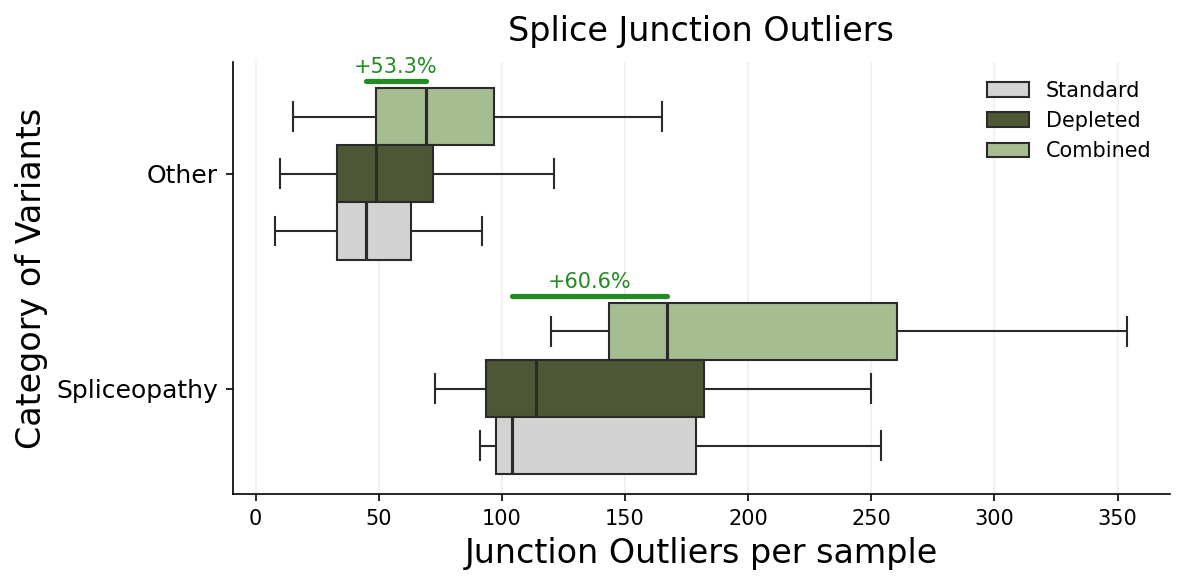

In [8]:
# ---- Compute counts per sample × splice × condition ----
def compute_outlier_counts_by_splice_effects(df):
    """
    Count unique junctions per sample x splice x condition.
    Adds a Combined condition (union of Standard + Depleted per sample x splice).
    """
    base = (
        df.groupby(["sample", "splice", "condition"])["junction"]
        .nunique()
        .reset_index()
        .rename(columns={"junction": "count"})
    )

    combined = (
        df.groupby(["sample", "splice"])["junction"]
        .nunique()
        .reset_index()
        .assign(condition="Combined")
        .rename(columns={"junction": "count"})
    )

    total = pd.concat([base, combined], ignore_index=True)
    # Order Combined → Depleted → Standard
    total["condition"] = pd.Categorical(
        total["condition"], categories=["Combined", "Depleted", "Standard"], ordered=True
    )
    return total


# ---- Build tidy data ----
tidy_counts = compute_outlier_counts_by_splice_effects(combined_effects)

# ---- Plot ----
plt.figure(figsize=(8, 4), dpi=150)
palette = {"Standard": "lightgrey", "Depleted": "#4F5D2F", "Combined": "#A6C48A"}
ax = sns.boxplot(
    data=tidy_counts,
    x="count",
    y="splice",
    hue="condition",
    palette=palette,
    linewidth=0.8,
    fliersize=2,
    showfliers=False,
    width=0.8,
    medianprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0),
)

plt.xlabel("Junction Outliers per sample", fontsize=16)
plt.ylabel("Category of Variants", fontsize=16)
plt.title("Splice Junction Outliers", fontsize=16, pad=10)
plt.grid(axis="x", alpha=0.2)
#reverse the order of the legend entries
handles, labels = ax.get_legend_handles_labels()
handles = handles[::-1]
labels = labels[::-1]
ax.legend(handles, labels, frameon=False, loc="upper right")
plt.yticks(fontsize=12)
sns.despine()

# ---- Add green lines showing % gain Combined vs Standard ----
for i, sp in enumerate(ax.get_yticklabels()):
    splice_label = sp.get_text()
    subset = tidy_counts[tidy_counts["splice"] == splice_label]

    if not all(c in subset["condition"].unique() for c in ["Standard", "Combined"]):
        continue

    med_std = np.median(subset.loc[subset["condition"] == "Standard", "count"])
    print(med_std)
    med_comb = np.median(subset.loc[subset["condition"] == "Combined", "count"])
    print(med_comb)
    if med_std == 0:
        continue

    pct_gain = ((med_comb - med_std) / med_std) * 100.0

    # Get the y position of this splice row (from 0 at top → N-1 at bottom)
    y_pos = i
    # Line just above the Combined boxes
    y_line = y_pos - 0.43

    # Draw horizontal line from median(Standard) to median(Combined)
    ax.plot(
        [med_std, med_comb],
        [y_line, y_line],
        color="forestgreen",
        linewidth=2.5,
        solid_capstyle="round",
        zorder=5,
    )

    # Label above line
    ax.text(
        (med_std + med_comb) / 2,
        y_line - 0.02,
        f"+{pct_gain:.1f}%",
        color="forestgreen",
        fontsize=10,
        ha="center",
        va="bottom",
        zorder=6,
    )

plt.tight_layout()
plt.savefig("applied_depletion_gregor_n100/paper_figures/splice_junction_outliers.png", dpi=300)
plt.show()

In [9]:
#get the median counts per condition ignoring spliceopathy category
tidy_counts.groupby(['condition', 'splice'])['count'].median()

/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_88437/237784825.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tidy_counts.groupby(['condition', 'splice'])['count'].median()


condition  splice      
Combined   Other            69.0
           Spliceopathy    167.0
Depleted   Other            49.0
           Spliceopathy    114.0
Standard   Other            45.0
           Spliceopathy    104.0
Name: count, dtype: float64

In [10]:
tidy_counts.groupby(['condition'])['count'].median()

/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_88437/932184929.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tidy_counts.groupby(['condition'])['count'].median()


condition
Combined    71.5
Depleted    49.5
Standard    45.5
Name: count, dtype: float64

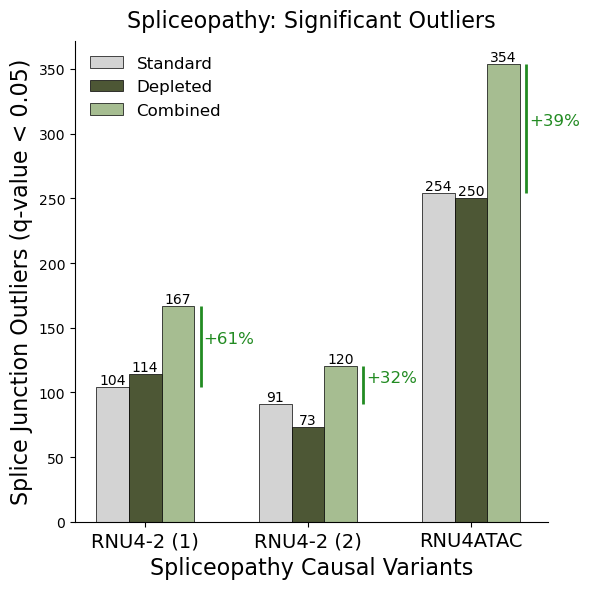

In [11]:
# --- Prepare data as before ---
splice = combined_effects[combined_effects['splice'] == 'Spliceopathy'].copy()
sample_rename = {'3-2': 'RNU4ATAC', '5-4': 'RNU4-2 (1)', '5-7': 'RNU4-2 (2)'}
splice['sample'] = splice['sample'].replace(sample_rename)

# Counts per sample per condition
counts_std_dep = splice.groupby(['sample', 'condition'])['junction'].nunique().reset_index()
counts_std_dep.rename(columns={'junction': 'count'}, inplace=True)

# Combined = unique junctions across both Standard + Depleted
combined_counts = (
    splice.groupby('sample')['junction']
    .nunique()
    .reset_index()
    .assign(condition='Combined')
    .rename(columns={'junction': 'count'})
)

total_counts = pd.concat([counts_std_dep, combined_counts], ignore_index=True)

# Order conditions
condition_order = ['Standard', 'Depleted', 'Combined']
total_counts['condition'] = pd.Categorical(total_counts['condition'], categories=condition_order, ordered=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 6))
sns.barplot(
    data=total_counts,
    x='sample',
    y='count',
    hue='condition',
    palette=['lightgrey', '#4F5D2F', '#A6C48A'],
    edgecolor='black',
    linewidth=0.5,
    width=0.6,
    ax=ax
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

# Identify bar containers by hue order (must match your palette / condition_order)
condition_order = ['Standard', 'Depleted', 'Combined']
containers = ax.containers  # list[BarContainer], one per hue in order

# Map hue -> container index
hue_to_idx = {h: i for i, h in enumerate(condition_order)}

# Short-cuts to the two we need
std_idx = hue_to_idx['Standard']
comb_idx = hue_to_idx['Combined']

# Safety: ensure we have both containers
if std_idx < len(containers) and comb_idx < len(containers):
    std_bars  = containers[std_idx]
    comb_bars = containers[comb_idx]

    # Iterate over samples (bars align by index across containers)
    for k, comb_bar in enumerate(comb_bars):
        # Combined bar geometry
        x_comb_left  = comb_bar.get_x()
        w_comb       = comb_bar.get_width()
        x_comb_right = x_comb_left + w_comb
        h_comb       = comb_bar.get_height()

        # Matching Standard bar
        if k >= len(std_bars):
            continue
        h_std = std_bars[k].get_height()

        # If either bar missing, skip
        if h_std is None or h_comb is None:
            continue

        # Percent gain relative to Standard
        pct_gain = ((h_comb - h_std) / h_std * 100.0) if h_std != 0 else np.nan

        # Vertical line just to the RIGHT of the combined bar
        x_line = x_comb_right + (0.20 * w_comb)  # nudge right ~6% of a bar width
        y0, y1 = sorted([h_std, h_comb])

        ax.vlines(x_line, y0, y1, colors='forestgreen', linewidth=2)

        # Percent label to the right of the line, slightly above the higher value
        label = f"{pct_gain:+.0f}%" if np.isfinite(pct_gain) else "NA"
        ax.text(
            x_line + 0.08 * w_comb,   # further right
            (y0 + y1) / 2,             # make it in the middle of the line
            label,
            color='forestgreen',
            fontsize=12,
            va='bottom',
            ha='left'
        )

# Style
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), fontsize=14)
plt.xlabel("Spliceopathy Causal Variants", fontsize=16)
plt.ylabel("Splice Junction Outliers (q-value < 0.05)", fontsize=16)
plt.title("Spliceopathy: Significant Outliers", fontsize=16, pad=10)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig("applied_depletion_gregor_n100/paper_figures/splice_junction_outliers_spliceopathy_barplot.png", dpi=300)
plt.show()

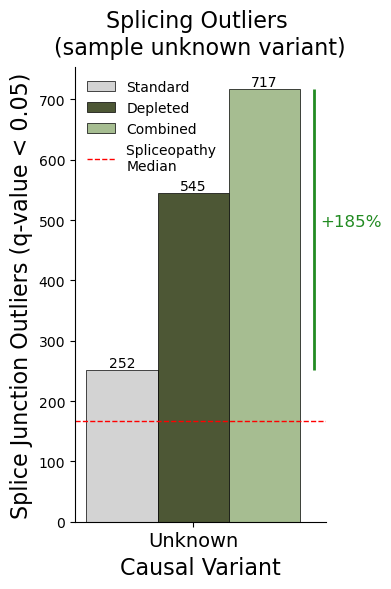

In [59]:
splice = combined_effects[combined_effects['sample'] == '1-6'].copy()
sample_rename = {'1-6': 'Unknown'}
splice['sample'] = splice['sample'].replace(sample_rename)

# Counts per sample per condition
counts_std_dep = splice.groupby(['sample', 'condition'])['junction'].nunique().reset_index()
counts_std_dep.rename(columns={'junction': 'count'}, inplace=True)

# Combined = unique junctions across both Standard + Depleted
combined_counts = (
    splice.groupby('sample')['junction']
    .nunique()
    .reset_index()
    .assign(condition='Combined')
    .rename(columns={'junction': 'count'})
)

total_counts = pd.concat([counts_std_dep, combined_counts], ignore_index=True)

# Order conditions
condition_order = ['Standard', 'Depleted', 'Combined']
total_counts['condition'] = pd.Categorical(total_counts['condition'], categories=condition_order, ordered=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(4, 6))
sns.barplot(
    data=total_counts,
    x='sample',
    y='count',
    hue='condition',
    palette=['lightgrey', '#4F5D2F', '#A6C48A'],
    edgecolor='black',
    linewidth=0.5,
    width=0.6,
    ax=ax
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

# Identify bar containers by hue order (must match your palette / condition_order)
condition_order = ['Standard', 'Depleted', 'Combined']
containers = ax.containers  # list[BarContainer], one per hue in order

# Map hue -> container index
hue_to_idx = {h: i for i, h in enumerate(condition_order)}

# Short-cuts to the two we need
std_idx = hue_to_idx['Standard']
comb_idx = hue_to_idx['Combined']

# Safety: ensure we have both containers
if std_idx < len(containers) and comb_idx < len(containers):
    std_bars  = containers[std_idx]
    comb_bars = containers[comb_idx]

    # Iterate over samples (bars align by index across containers)
    for k, comb_bar in enumerate(comb_bars):
        # Combined bar geometry
        x_comb_left  = comb_bar.get_x()
        w_comb       = comb_bar.get_width()
        x_comb_right = x_comb_left + w_comb
        h_comb       = comb_bar.get_height()

        # Matching Standard bar
        if k >= len(std_bars):
            continue
        h_std = std_bars[k].get_height()

        # If either bar missing, skip
        if h_std is None or h_comb is None:
            continue

        # Percent gain relative to Standard
        pct_gain = ((h_comb - h_std) / h_std * 100.0) if h_std != 0 else np.nan

        # Vertical line just to the RIGHT of the combined bar
        x_line = x_comb_right + (0.20 * w_comb)  # nudge right ~6% of a bar width
        y0, y1 = sorted([h_std, h_comb])

        ax.vlines(x_line, y0, y1, colors='forestgreen', linewidth=2)

        # Percent label to the right of the line, slightly above the higher value
        label = f"{pct_gain:+.0f}%" if np.isfinite(pct_gain) else "NA"
        ax.text(
            x_line + 0.08 * w_comb,   # further right
            (y0 + y1) / 2,             # make it in the middle of the line
            label,
            color='forestgreen',
            fontsize=12,
            va='bottom',
            ha='left'
        )

#add a dashed red line at y=167 called spliceopathy
ax.axhline(y=167, color='red', linestyle='--', linewidth=1, label='Spliceopathy \nMedian')
# Style
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), fontsize=14)
plt.xlabel("Causal Variant", fontsize=16)
plt.ylabel("Splice Junction Outliers (q-value < 0.05)", fontsize=16)
plt.title("Splicing Outliers \n(sample unknown variant)", fontsize=16, pad=10)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("applied_depletion_gregor_n100/paper_figures/splice_junction_outliers_sample1-6_barplot.png", dpi=300)
plt.show()

In [14]:
#these are all of the spliucing outliers found in the spliceopathy samples
spliceop = pd.read_csv("applied_depletion_gregor_n100/leafcutter/spliceopathy_samples_splicing_outliers.csv")
spliceop['condition'] = spliceop['condition'].replace({'Control': 'Standard'})
spliceop

,sample,effect_size,junction,condition,cluster,effect_size_category
0,5-7,0.717665,chr1:120461333:120462874:clu_17707_+,Depleted,clu_17707_+,intron retention
1,3-2,0.715084,chr7:102549283:102648390:clu_51371_+,Standard,clu_51371_+,intron retention
2,3-2,0.695120,chr11:119011283:119011939:clu_49363_+,Standard,clu_49363_+,intron retention
3,3-2,0.689160,chr11:119011283:119011939:clu_49363_+,Depleted,clu_49363_+,intron retention
4,3-2,0.687471,chr16:89398214:89398337:clu_31371_-,Standard,clu_31371_-,intron retention
...,...,...,...,...,...,...
881,3-2,-0.625550,chr7:105160613:105167377:clu_45381_-,Depleted,clu_45381_-,intron skipping
882,3-2,-0.654281,chr2:166307074:166311499:clu_15738_-,Standard,clu_15738_-,intron skipping
883,3-2,-0.661549,chr7:111758790:111760181:clu_45429_-,Depleted,clu_45429_-,intron skipping
884,3-2,-0.661725,chr11:119011311:119011939:clu_49363_+,Depleted,clu_49363_+,intron skipping


In [15]:
#now read in the gene overlap file 
gene_overlap = pd.read_csv("applied_depletion_gregor_n100/leafcutter/spliceopathy_samples_splicing_outliers_gene_overlap.tsv", sep="\t", header=None)
gene_overlap['gene_name'] = gene_overlap[9].str.split(';').str[1]
gene_overlap['junction'] = gene_overlap[3]

# Map gene names to splice junctions
spliceop['gene_name'] = spliceop['junction'].apply(
    lambda x: ', '.join(gene_overlap.loc[gene_overlap['junction'] == x, 'gene_name'].unique())
)

# get the outlier junctions only found in depleted
depleted_spliceop = spliceop[spliceop['condition'] == 'Depleted']
control_spliceop = spliceop[spliceop['condition'] == 'Standard']
specific = depleted_spliceop[~depleted_spliceop['junction'].isin(control_spliceop['junction'])]
specific.head(20)

,sample,effect_size,junction,condition,cluster,effect_size_category,gene_name
0,5-7,0.717665,chr1:120461333:120462874:clu_17707_+,Depleted,clu_17707_+,intron retention,NBPF8
6,3-2,0.646110,chr16:89828794:89845322:clu_6819_+,Depleted,clu_6819_+,intron retention,SPIRE2
12,5-7,0.577912,chr3:113291748:113294687:clu_4792_-,Depleted,clu_4792_-,intron retention,CFAP44
21,5-4,0.486554,chr3:174441032:174550569:clu_23953_+,Depleted,clu_23953_+,intron retention,NAALADL2
24,5-7,0.468036,chr6:32642253:32642610:clu_29265_+,Depleted,clu_29265_+,intron retention,HLA-DQA1
25,3-2,0.461117,chr21:37816250:37840428:clu_11715_+,Depleted,clu_11715_+,intron retention,"ENSG00000292435, ENSG00000289538"
32,3-2,0.449270,chr21:41860372:41863235:clu_46918_-,Depleted,clu_46918_-,intron retention,PRDM15
47,5-7,0.405858,chr14:50438094:50440013:clu_20566_-,Depleted,clu_20566_-,intron retention,MAP4K5
48,5-4,0.404654,chr2:178672267:178672635:clu_15816_-,Depleted,clu_15816_-,intron retention,TTN
52,5-4,0.391173,chr8:2193015:2195429:clu_26816_+,Depleted,clu_26816_+,intron retention,ENSG00000288782


In [16]:
# junctions to genes for RNU4ATAC
specific32 = specific[specific['sample'] == '3-2']
total_genes = set()
for gene_list in specific32['gene_name'].str.split(', '):
    total_genes.update(gene_list)
total_genes = sorted(total_genes)
total_genes = [gene for gene in total_genes if not gene.startswith('ENSG')]
total_genes = [gene for gene in total_genes if not gene=='']
print(len(total_genes))
with open("applied_depletion_gregor_n100/paper_figures/Genes_from_splice_outliers_only_from_depleted_spliceopathy_3-2.txt", "w") as f:
    for gene in total_genes:
        f.write(f"{gene}\n")

86


In [17]:
#get a list of all depletion specific genes 
total_genes = set()
for gene_list in specific['gene_name'].str.split(', '):
    total_genes.update(gene_list)
total_genes = sorted(total_genes)
total_genes = [gene for gene in total_genes if not gene.startswith('ENSG')]
total_genes = [gene for gene in total_genes if not gene=='']
print(len(total_genes))
with open("applied_depletion_gregor_n100/paper_figures/Genes_from_splice_outliers_only_from_depleted_spliceopathy.txt", "w") as f:
    for gene in total_genes:
        f.write(f"{gene}\n")

155


In [18]:
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
def plot_enrichment_lollipop(df: pd.DataFrame, 
                             top_n=10, 
                             title="Top Enriched Terms",
                             save=False,
                             savefile="GREGOR_GUIDE/figures/enrichment_lollipop.png"):
    """
    Lollipop chart for enrichment results with:
      - X: Combined Score
      - Y: Term
      - Dot size: Overlap Count
      - Dot color: -log10(P-value) (darker green = more significant)
      - Right-side: colorbar (-log10(P-value)) + bubble size legend
    """

    # --- Check columns ---
    required_cols = ["Term", "Overlap", "P-value", "Adjusted P-value", "Combined Score"]
    if not all(c in df.columns for c in required_cols):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")

    # Work on a copy
    df = df.copy()

    # Parse "157/796" -> 157
    df["Overlap Count"] = df["Overlap"].astype(str).str.split("/").str[0].astype(int)

    # Compute -log10(P-value) for color mapping
    # Protect against p=0
    df["-log10 P"] = -np.log10(df["P-value"].clip(lower=1e-300))

    # Select top terms by highest Combined Score
    top_df = df.nlargest(top_n, "Combined Score").iloc[::-1]  # reverse for top-down plotting

    # --- Colormap setup ---
    # darkest green = highest -log10(P)
    cmap = mpl.cm.Greens
    vmin, vmax = top_df["-log10 P"].min(), top_df["-log10 P"].max()
    if vmin == vmax:
        vmax = vmin + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # --- Plot setup ---
    fig, ax = plt.subplots(figsize=(3.8, 0.3 * top_n + 0.6), dpi=150)
    y_positions = np.arange(len(top_df))

    # Lollipop stems
    ax.hlines(
        y=y_positions,
        xmin=0,
        xmax=top_df["Combined Score"],
        color="lightgray",
        lw=2,
        zorder=1
    )

    # Size scaling
    def size_scale(n_genes):
        return np.sqrt(n_genes) * 20

    # Scatter points
    sc = ax.scatter(
        top_df["Combined Score"],
        y_positions,
        s=size_scale(top_df["Overlap Count"]),
        c=top_df["-log10 P"],
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    # --- Axes formatting ---
    ax.set_yticks(y_positions)
    ax.set_yticklabels(top_df["Term"], fontsize=11)
    ax.set_xlabel("Combined Score", fontsize=13)
    ax.set_ylabel("")
    ax.set_title(title, fontsize=15, pad=15)

    # Add vertical padding so top/bottom circles do not get cut off
    ax.set_ylim(-0.75, len(top_df) - 0.25)

    # Give a bit of right margin for colorbar + size legend
    plt.subplots_adjust(right=0.78)

    # --- Right-side colorbar (-log10(P-value)) ---
    cax = inset_axes(
        ax,
        width="3%",
        height="55%",
        loc="center left",
        bbox_to_anchor=(1.1, 0.12, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label("-log10(P-value)", fontsize=9, rotation=270, labelpad=14)
    cbar.ax.tick_params(labelsize=9)

    # --- Bubble size legend ---
    sax = inset_axes(
        ax,
        width="16%",
        height="28%",
        loc="lower left",
        bbox_to_anchor=(1.01, -0.3, 1, 1.8),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    sax.set_xlim(0, 1)
    sax.set_ylim(0, 1)
    sax.axis("off")

    bubble_vals = [50, 25, 5]
    ys = [0.7, 0.45, 0.2]
    x_bub = 0.35
    x_txt = 0.68

    for y, v in zip(ys, bubble_vals):
        sax.scatter(
            x_bub, y,
            s=size_scale(v),
            facecolor="lightgray",
            edgecolor="black",
            linewidth=0.5
        )
        sax.text(x_txt, y, f"{v}", va="center", ha="left", fontsize=9)

    sax.text(0.0, 0.95, "Overlap size", fontsize=10)

    # --- Styling ---
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    if save:
        plt.savefig(savefile, dpi=400, bbox_inches="tight")

    plt.show()

    return top_df

In [19]:
data = pd.read_csv('applied_depletion_gregor_n100/paper_figures/Splice_junctions_RNU4ATAC_GO_Molecular_Function_2025_table.txt', delimiter='\t')
data = data[data['Adjusted P-value'] < 0.05]
data = data.sort_values(by='Combined Score', ascending=False)
#remove the stuff in parenthesis from Term
data['Term'] = data['Term'].str.replace(r'\s*\(.*\)', '', regex=True)
data.head(10)

,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,Metal Cation:Proton Antiporter Activity,3/21,0.000097,0.009074,0,0,39.951807,369.380218,SLC30A5;SLC9A8;SLC9A9
1,Potassium:Proton Antiporter Activity,2/11,0.000980,0.043311,0,0,52.658730,364.810359,SLC9A8;SLC9A9
2,Sodium:Proton Antiporter Activity,2/13,0.001382,0.043311,0,0,43.080087,283.640874,SLC9A8;SLC9A9
3,Solute:Potassium Antiporter Activity,2/15,0.001850,0.043484,0,0,36.448718,229.348878,SLC9A8;SLC9A9


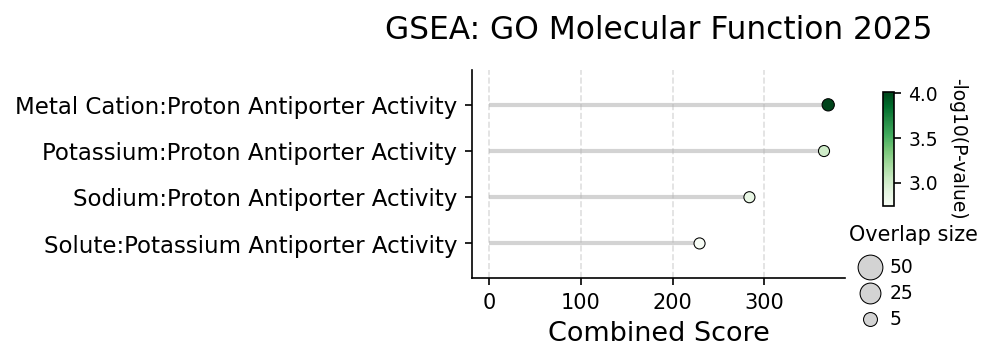

In [20]:
top_df = plot_enrichment_lollipop(data, top_n=4, title="GSEA: GO Molecular Function 2025", save=True, 
                                 savefile="applied_depletion_gregor_n100/paper_figures/RNU4ATAC_GO_Molecular_Function_2025_enrichment_lollipop.png")

Now focus on frazier and MIG intron retention events for RNU4ATAC
-

In [16]:
data = pd.read_csv("applied_depletion_gregor_n100/frazier/MIG_compare_junction_values_unique_shared.csv")
data['length'] = data['Gene_names'].str.count(',') + 1
parts = data['sampleID'].str.split('_')
data['sample name'] = parts.str[0] + '_' + parts.str[1]
data['parameter'] = parts.str[2]
data['threshold'] = parts.str[3]
data = data.sort_values(by='length', ascending=False)
data = data[(data['parameter']=='psi5')&(data['threshold']=='05')&(data['sample name']=='3_2')]
data = data.sort_values(by='length', ascending=False)
data

,sampleID,Type,Gene_names,length,sample name,parameter,threshold
413,3_2_psi5_05,Shared,"chr7_SRPK2_105160614_105167376, chr7_UBE2H_129...",15.0,3_2,psi5,05
411,3_2_psi5_05,Unique_Depletion,"chr1_CRTC2_153953607_153954254, chr1_CRTC2_153...",12.0,3_2,psi5,05
412,3_2_psi5_05,Unique_Control,"chr7_SRPK2_105160614_105165885, chr2_HNRNPLL_3...",7.0,3_2,psi5,05


In [17]:
#for each comma seperated item in Gene_names, split and get the unique second value after '_' 
unique_genes = set()
for gene_list in data[data['Type']=='Unique_Depletion']['Gene_names']:
    genes = gene_list.split(',')
    for gene in genes:
        parts = gene.split('_')
        if len(parts) > 1:
            unique_genes.add(parts[1])
unique_genes = sorted(unique_genes)
unique_genes

['CCPG1',
 'CRTC2',
 'DRAM1',
 'DRAM2',
 'PDPK1',
 'RNPC3',
 'SLC12A6',
 'SLC9A7',
 'SPCS2',
 'ZCCHC8']

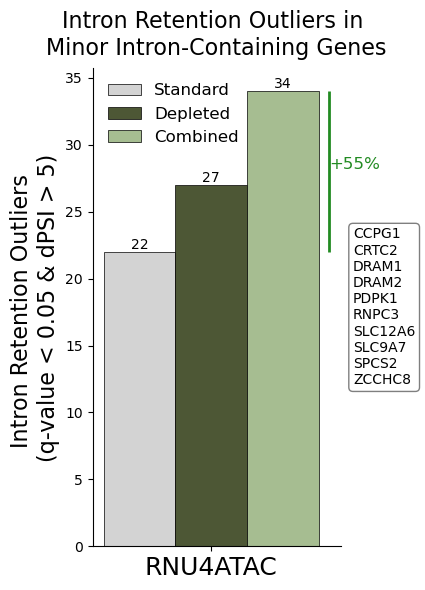

In [ ]:
counts_shared = data[data['Type']=='Shared']['length'].values[0]
counts_depleted = data[data['Type']=='Unique_Depletion']['length'].values[0]
counts_control = data[data['Type']=='Unique_Control']['length'].values[0]

standard = counts_control + counts_shared
depleted = counts_depleted + counts_shared
combined = counts_control + counts_depleted + counts_shared

counts = pd.DataFrame()
counts['condition'] = ['Standard', 'Depleted', 'Combined']
counts['count'] = [standard, depleted, combined]
counts['sample'] = 'RNU4ATAC'

#plot seaborn barplot of counts, hue is condition, x is sample, y is count
fig, ax = plt.subplots(figsize=(4.4, 6))
sns.barplot(
    data=counts,
    x='sample',
    y='count',
    hue='condition',
    palette=['lightgrey', '#4F5D2F', '#A6C48A'],
    edgecolor='black',
    linewidth=0.5,
    width=0.4,
    ax=ax
)
#add a green line showing percent gain from standard to combined
std_height = standard
comb_height = combined
pct_gain = ((comb_height - std_height) / std_height) * 100.0
x_line = 0.22  # nudge right ~6% of a bar width
y0, y1 = sorted([std_height, comb_height])
ax.vlines(x_line, y0, y1, colors='forestgreen', linewidth=2)
# Percent label to the right of the line, slightly above the higher value
label = f"{pct_gain:+.0f}%"
ax.text(
    x_line ,   
    (y0 + y1) / 2,             
    label,
    color='forestgreen',
    fontsize=12,
    va='bottom',
    ha='left'
)
# Add count labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

#to the right of the barplot, add a text box with the unique genes in a sinlgle column
unique_genes_text = "\n".join(unique_genes)
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
ax.text(1.05, 0.5, unique_genes_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='center', bbox=props)
# Style
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), fontsize=18)
plt.xlabel("", fontsize=16)
plt.ylabel("Intron Retention Outliers \n(q-value < 0.05 & dPSI > 5)", fontsize=16)
plt.title("Intron Retention Outliers in \nMinor Intron-Containing Genes", fontsize=16, pad=10)
plt.legend(frameon=False, fontsize=12, loc="upper left")
plt.tight_layout()
plt.savefig("applied_depletion_gregor_n100/paper_figures/intron_retention_MIG_outliers_barplot.png", dpi=300)
plt.show()

In [283]:
data.to_csv("applied_depletion_gregor_n100/paper_figures/intron_retention_MIG_RNU4ATAC_outliers_data.csv", index=False)